In [1]:
print(1)

1


In [2]:
import glob
import os
import random

import numpy as np
import pandas as pd
import rasterio


## Utils

In [3]:


def calcular_classes_mascara(tif_path, nodata=None):
    """
    Calcula a quantidade e a porcentagem de pixels de cada classe da máscara.

    Parameters
    ----------
    tif_path : str
        Caminho para o arquivo TIFF.
    nodata : int ou float, optional
        Valor NoData. Se None, utiliza o valor definido no raster.

    Returns
    -------
    dict
        {
            classe: {
                "pixels": quantidade,
                "percentual": percentual
            },
            ...
        }
    """
    with rasterio.open(tif_path) as src:
        mask = src.read(1)


    classes, counts = np.unique(mask, return_counts=True)
    total = counts.sum()
    
    # print("mask.size:", mask.size)

    classes, counts = np.unique(mask, return_counts=True)
    # print("soma:", counts.sum())

    return {
        int(classe): {
            "pixels": int(count),
            "percentual": float(count / total * 100)
        }
        for classe, count in zip(classes, counts)
    }

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import rasterio

def visualizar_mascara(tif_path, figsize=(8, 8)):
    with rasterio.open(tif_path) as src:
        mask = src.read(1)

    # Classes presentes
    classes = np.unique(mask)

    # Reindexa as classes para 0,1,2,...
    idx = {c: i for i, c in enumerate(classes)}
    mask_plot = np.vectorize(idx.get)(mask)

    # Uma cor por classe
    # cmap = ListedColormap(plt.cm.tab20.colors[:len(classes)])

    plt.figure(figsize=figsize)
    im = plt.imshow(mask_plot, cmap="gray", interpolation="nearest")

    # # Barra de cores mostrando os valores reais das classes
    # cbar = plt.colorbar(im, ticks=np.arange(len(classes)))
    # cbar.ax.set_yticklabels(classes)

    plt.axis("off")
    plt.title("Máscara")
    plt.show()

## Get Images

In [5]:
reservoirs = [f for f in os.listdir("D:/GeoPipe/data/03_cloud_masks") if not '.' in f]

In [6]:
reservoirs

['argemiro', 'engenheiro_avidos', 'gramame', 'lagoa_do_arroz', 'mares', 'sume']

In [7]:
images = []

for reservoir in reservoirs:
    images += glob.glob(f"D:/GeoPipe/data/03_cloud_masks/{reservoir}/fmask/**/*.tif")

In [8]:
len(images)

4022

In [9]:
images[:5]

['D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\\2017\\mask_sentinel_TOA_S2_argemiro_20170103.tif',
 'D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\\2017\\mask_sentinel_TOA_S2_argemiro_20170123.tif',
 'D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\\2017\\mask_sentinel_TOA_S2_argemiro_20170202.tif',
 'D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\\2017\\mask_sentinel_TOA_S2_argemiro_20170212.tif',
 'D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\\2017\\mask_sentinel_TOA_S2_argemiro_20170304.tif']

## One image test

In [10]:
with rasterio.open(images[0]) as src:
    print("NoData:", src.nodata)

    mask = src.read(1)

    classes, counts = np.unique(mask, return_counts=True)
    print(dict(zip(classes, counts)))

NoData: 0.0
{0: 147330, 1: 1438924, 2: 3254}


In [11]:
random_image = random.choice(images)
calcular_classes_mascara(random_image)

{0: {'pixels': 39, 'percentual': 0.013011710539485537},
 1: {'pixels': 299691, 'percentual': 99.98698828946051}}

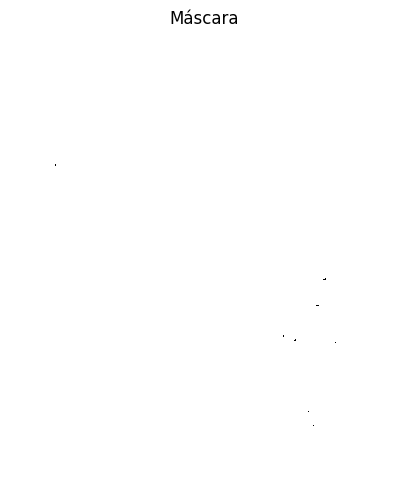

In [12]:
visualizar_mascara(random_image, figsize=(5, 10))

## Generate Dataframe

In [13]:
images_dicts = []

for image in images:
    line = {}
    classes_info = calcular_classes_mascara(image)
    line["image"] = image
    line['cloud_pixels'] = classes_info.get(1, {}).get("percentual", 0)
    line['cloud_shadow_pixels'] = classes_info.get(2, {}).get("percentual", 0)
    images_dicts.append(line)
    print(f"Image: {image}")


Image: D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\2017\mask_sentinel_TOA_S2_argemiro_20170103.tif
Image: D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\2017\mask_sentinel_TOA_S2_argemiro_20170123.tif
Image: D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\2017\mask_sentinel_TOA_S2_argemiro_20170202.tif
Image: D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\2017\mask_sentinel_TOA_S2_argemiro_20170212.tif
Image: D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\2017\mask_sentinel_TOA_S2_argemiro_20170304.tif
Image: D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\2017\mask_sentinel_TOA_S2_argemiro_20170413.tif
Image: D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\2017\mask_sentinel_TOA_S2_argemiro_20170503.tif
Image: D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\2017\mask_sentinel_TOA_S2_argemiro_20170523.tif
Image: D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\2017\mask_sentinel_TOA_S2_argemiro_20170612.tif
Image: D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\2017\mask_sentinel_TOA_S2_argemiro_201

In [14]:
images_df = pd.DataFrame(images_dicts)

In [15]:
images_df[:5]

,image,cloud_pixels,cloud_shadow_pixels
0,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,90.526377,0.204717
1,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,58.810714,10.466761
2,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,22.261857,10.614605
3,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,92.981036,0.014722
4,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,32.915657,5.351845


In [16]:
images_df["reservoir"] = images_df["image"].apply(lambda x: x.split("/")[4])

In [17]:
images_df[:5]

,image,cloud_pixels,cloud_shadow_pixels,reservoir
0,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,90.526377,0.204717,argemiro
1,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,58.810714,10.466761,argemiro
2,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,22.261857,10.614605,argemiro
3,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,92.981036,0.014722,argemiro
4,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,32.915657,5.351845,argemiro


In [18]:
# rename columns
images_df.rename(columns={
    "image": "mask",
    "cloud_pixels": "cloud_percentage",
    "cloud_shadow_pixels": "cloud_shadow_percentage"
}, inplace=True)

## Get Corresponding BOA image

In [19]:
images = []

for reservoir in reservoirs:
    images += glob.glob(f"D:/GeoPipe/data/02_boa_images/{reservoir}/**/*.tif")

In [20]:
images[:5]

['D:/GeoPipe/data/02_boa_images/argemiro\\2018\\sentinel_BOA_S2_SR_argemiro_20180612.tif',
 'D:/GeoPipe/data/02_boa_images/argemiro\\2018\\sentinel_BOA_S2_SR_argemiro_20181214.tif',
 'D:/GeoPipe/data/02_boa_images/argemiro\\2018\\sentinel_BOA_S2_SR_argemiro_20181219.tif',
 'D:/GeoPipe/data/02_boa_images/argemiro\\2018\\sentinel_BOA_S2_SR_argemiro_20181224.tif',
 'D:/GeoPipe/data/02_boa_images/argemiro\\2018\\sentinel_BOA_S2_SR_argemiro_20181229.tif']

In [21]:
from pathlib import Path
import pandas as pd
import re

import re

pattern = re.compile(
    r".*_(?P<area>[^_]+)_(?P<date>\d{8})\.tif$",
    re.IGNORECASE
)

def make_key(path):
    path = path.replace("\\", "/")
    m = pattern.search(path)
    if m is None:
        return None
    return m.group("area"), m.group("date")


def add_image_path(df: pd.DataFrame,
                   mask_column: str,
                   image_paths: list[str],
                   missing_value=None) -> pd.DataFrame:
    """
    Adiciona ao dataframe uma coluna 'image_path' contendo o caminho
    da imagem correspondente à máscara.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame contendo os paths das máscaras.
    mask_column : str
        Nome da coluna com os paths das máscaras.
    image_paths : list[str]
        Lista dos paths das imagens.
    missing_value : any
        Valor para imagens não encontradas (default=None).

    Returns
    -------
    pd.DataFrame
    """

    # índice das imagens
    image_dict = {
        make_key(img): img
        for img in image_paths
    }

    # cria a coluna
    df = df.copy()
    df["image_path"] = (
        df[mask_column]
        .map(lambda x: image_dict.get(make_key(x), missing_value))
    )

    return df

In [22]:
df = add_image_path(
    df=images_df,
    mask_column="mask",
    image_paths=images,
    missing_value=pd.NA
)

In [23]:
df

,mask,cloud_percentage,cloud_shadow_percentage,reservoir,image_path
0,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,90.526377,0.204717,argemiro,<NA>
1,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,58.810714,10.466761,argemiro,<NA>
2,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,22.261857,10.614605,argemiro,<NA>
3,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,92.981036,0.014722,argemiro,<NA>
4,D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\...,32.915657,5.351845,argemiro,<NA>
...,...,...,...,...,...
4017,D:/GeoPipe/data/03_cloud_masks/sume/fmask\2026...,97.594168,1.140026,sume,D:/GeoPipe/data/02_boa_images/sume\2026\sentin...
4018,D:/GeoPipe/data/03_cloud_masks/sume/fmask\2026...,70.606212,7.679245,sume,D:/GeoPipe/data/02_boa_images/sume\2026\sentin...
4019,D:/GeoPipe/data/03_cloud_masks/sume/fmask\2026...,57.586828,12.633036,sume,D:/GeoPipe/data/02_boa_images/sume\2026\sentin...
4020,D:/GeoPipe/data/03_cloud_masks/sume/fmask\2026...,99.828512,0.003336,sume,D:/GeoPipe/data/02_boa_images/sume\2026\sentin...


In [24]:
df[500:505]['mask'].to_list(), df[500:505]['image_path'].to_list()

(['D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\\2024\\mask_sentinel_TOA_S2_argemiro_20241217.tif',
  'D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\\2024\\mask_sentinel_TOA_S2_argemiro_20241222.tif',
  'D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\\2024\\mask_sentinel_TOA_S2_argemiro_20241227.tif',
  'D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\\2025\\mask_sentinel_TOA_S2_argemiro_20250101.tif',
  'D:/GeoPipe/data/03_cloud_masks/argemiro/fmask\\2025\\mask_sentinel_TOA_S2_argemiro_20250106.tif'],
 ['D:/GeoPipe/data/02_boa_images/argemiro\\2024\\sentinel_BOA_S2_SR_argemiro_20241217.tif',
  'D:/GeoPipe/data/02_boa_images/argemiro\\2024\\sentinel_BOA_S2_SR_argemiro_20241222.tif',
  'D:/GeoPipe/data/02_boa_images/argemiro\\2024\\sentinel_BOA_S2_SR_argemiro_20241227.tif',
  'D:/GeoPipe/data/02_boa_images/argemiro\\2025\\sentinel_BOA_S2_SR_argemiro_20250101.tif',
  'D:/GeoPipe/data/02_boa_images/argemiro\\2025\\sentinel_BOA_S2_SR_argemiro_20250106.tif'])

In [25]:
df.dropna(subset=["image_path"], inplace=True)

In [26]:
len(df)

3534

In [27]:
imagess = []

for reservoir in reservoirs:
    imagess += glob.glob(f"D:/GeoPipe/data/04_clean_images/{reservoir}/fmask/**/**/*.tif")

In [28]:
len(imagess)

3357

## Filter cloud free images

In [29]:
df.describe()

,cloud_percentage,cloud_shadow_percentage
count,3534.000000,3534.000000
mean,50.278453,4.754618
std,37.561034,5.184587
min,0.000000,0.000000
25%,12.911349,0.333758
50%,45.415172,3.346025
75%,92.550414,7.542412
max,100.000000,58.863526


In [30]:
for percentage in [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]:
    count = len(df.loc[df['cloud_percentage'] <= percentage])
    print(f"Cloud percentage <= {percentage}%: {count} images")

Cloud percentage <= 0%: 5 images
Cloud percentage <= 10%: 791 images
Cloud percentage <= 20%: 1068 images
Cloud percentage <= 30%: 1353 images
Cloud percentage <= 40%: 1625 images
Cloud percentage <= 50%: 1867 images
Cloud percentage <= 60%: 2056 images
Cloud percentage <= 70%: 2220 images
Cloud percentage <= 80%: 2383 images
Cloud percentage <= 90%: 2589 images
Cloud percentage <= 100%: 3534 images


In [90]:
df_cloud_free = df.loc[df['cloud_percentage'] <= 10]

In [91]:
print("Quantidade de imagens por reservatório com nuvens <= 10%:")
images_cloud_free_count = {}
for reservoir in df_cloud_free['reservoir'].unique():
    count = df_cloud_free[df_cloud_free['reservoir'] == reservoir].shape[0]
    images_cloud_free_count[reservoir] = count
    print(f"  {reservoir}: {count}")

Quantidade de imagens por reservatório com nuvens <= 10%:
  argemiro: 31
  engenheiro_avidos: 236
  gramame: 8
  lagoa_do_arroz: 244
  mares: 61
  sume: 211


In [121]:
# Get imagens with cloud_percentage > 0 and <= 50
masks = df.loc[(df['cloud_percentage'] > 0) & (df['cloud_percentage'] <= 50)]

In [122]:
# rename with sufix all fields names
masks = masks.rename(columns=lambda x: f"random_{x}" if isinstance(x, (int, float, str)) else x)

In [124]:
masks.describe()

,random_cloud_percentage,random_cloud_shadow_percentage
count,1862.000000,1862.000000
mean,18.222168,7.156348
std,15.900543,5.325309
min,0.000092,0.000000
25%,2.485715,3.235071
50%,14.536036,6.280229
75%,31.989457,9.767040
max,49.973309,58.863526


In [125]:
masks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1862 entries, 46 to 4014
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   random_mask                     1862 non-null   object 
 1   random_cloud_percentage         1862 non-null   float64
 2   random_cloud_shadow_percentage  1862 non-null   float64
 3   random_reservoir                1862 non-null   object 
 4   random_image_path               1862 non-null   object 
dtypes: float64(2), object(3)
memory usage: 87.3+ KB


In [126]:
masks_sample = pd.DataFrame()

for reservoir in reservoirs:
    masks_sample = pd.concat([
        masks_sample,
        masks[masks['random_reservoir'] == reservoir].sample(n=images_cloud_free_count[reservoir], random_state=42)
    ])

In [127]:
masks_sample = masks_sample.drop(columns=['random_reservoir', 'random_image_path'])


In [128]:
for reservoir in df_cloud_free['reservoir'].unique():
    count = df_cloud_free[df_cloud_free['reservoir'] == reservoir].shape[0]
    print(f"  {reservoir}: {count}")

  argemiro: 31
  engenheiro_avidos: 236
  gramame: 8
  lagoa_do_arroz: 244
  mares: 61
  sume: 211


In [129]:
print(masks_sample.shape, df_cloud_free.shape)

(791, 3) (791, 5)


In [130]:
df1 = df_cloud_free.reset_index(drop=True)
df2 = masks_sample.reset_index(drop=True)
final_df = pd.concat([df1, df2], axis=1)

In [131]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791 entries, 0 to 790
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   mask                            791 non-null    object 
 1   cloud_percentage                791 non-null    float64
 2   cloud_shadow_percentage         791 non-null    float64
 3   reservoir                       791 non-null    object 
 4   image_path                      791 non-null    object 
 5   random_mask                     791 non-null    object 
 6   random_cloud_percentage         791 non-null    float64
 7   random_cloud_shadow_percentage  791 non-null    float64
dtypes: float64(4), object(4)
memory usage: 49.6+ KB


In [135]:
final_df.describe()

,cloud_percentage,cloud_shadow_percentage,random_cloud_percentage,random_cloud_shadow_percentage
count,791.000000,791.000000,791.000000,791.000000
mean,2.796508,4.426522,14.973166,6.827409
std,3.160285,4.385616,15.509177,5.639782
min,0.000000,0.000000,0.000092,0.015014
25%,0.039298,1.899787,0.840883,2.779461
50%,1.339873,3.277101,9.430462,5.685051
75%,5.358788,5.484274,27.594532,9.270819
max,9.999133,58.863526,49.904436,58.863526


In [133]:
final_df.to_csv("../data/temporal_interpolation_images.csv", index=False)